In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [105]:
file_path = "../data/raw/Credit Risk Dataset.xlsx"
df = pd.read_excel(
    file_path,
    sheet_name="Credit Risk Data"
)
df_dict = pd.read_excel(
    file_path,
    sheet_name="Data Dictionary"
)

In [106]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())
display(df_dict)

Rows: 32581
Columns: 29


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


,Column Name,Description
0,client_ID,Unique identifier for each client
1,person_age,Age of the applicant (years)
2,person_income,Annual income of the applicant (USD)
3,person_home_ownership,Home ownership status (RENT/OWN/MORTGAGE)
4,person_emp_length,Employment length (years)
5,loan_intent,"Purpose of the loan (PERSONAL, MEDICAL, EDUCAT..."
6,loan_grade,Credit grade assigned to the loan (A–G)
7,loan_amnt,Requested loan amount (USD)
8,loan_int_rate,Loan interest rate (%)
9,loan_status,"Loan repayment status (0 = non-default, 1 = de..."


# 1. Dataset Overview

## Objective

Understand the structure, grain, variables, data types and basic data-quality characteristics of the Nova Bank credit-risk dataset before performing business analysis and modeling.

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [108]:
profile = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "unique_count": df.nunique().values
})
display(profile)

,column,dtype,missing_count,missing_pct,unique_count
0,client_ID,object,0,0.00,32581
1,person_age,int64,0,0.00,58
2,person_income,int64,0,0.00,4295
3,person_home_ownership,object,0,0.00,4
4,person_emp_length,float64,895,2.75,36
5,loan_intent,object,0,0.00,6
6,loan_grade,object,0,0.00,7
7,loan_amnt,int64,0,0.00,753
8,loan_int_rate,float64,3116,9.56,348
9,loan_status,int64,0,0.00,2


# 2. Data Quality Validation

## 2.1 Business Key Validation

The dataset should contain one record per client/loan observation. 
`client_ID` is expected to uniquely identify each observation.

In [109]:
client_id_unique = df["client_ID"].is_unique
print("Is client_ID unique?", client_id_unique)
print("Number of unique client_IDs:", df["client_ID"].nunique())
print("Number of rows:", len(df))

Is client_ID unique? True
Number of unique client_IDs: 32581
Number of rows: 32581


## 2.2 Check duplicate

In [10]:
duplicate_rows = df.duplicated().sum()
print("Number of completely duplicated rows:", duplicate_rows)
duplicate_clients = df["client_ID"].duplicated().sum()
print("Number of duplicated client_IDs:", duplicate_clients)

Number of completely duplicated rows: 0
Number of duplicated client_IDs: 0


## 2.3 Validate the target variable

In [11]:
print(df["loan_status"].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [12]:
print(df["loan_status"].value_counts(normalize=True).mul(100).round(2))

loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64


In [13]:
print("Unique loan_status values:", sorted(df["loan_status"].unique()))

Unique loan_status values: [0, 1]


In [14]:
default_summary = pd.DataFrame({
    "Loan Status": df["loan_status"].value_counts().index,
    "Count": df["loan_status"].value_counts().values,
    "Percentage": (
        df["loan_status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .values
    )
})
display(default_summary)

,Loan Status,Count,Percentage
0,0,25473,78.18
1,1,7108,21.82


## 2.4 Check categorical variables

In [15]:
categorical_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file",
    "gender",
    "marital_status",
    "education_level",
    "country",
    "state",
    "city",
    "employment_type"
]
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)
    print(df[col].value_counts(dropna=False))


person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

gender
gender
Male      16371
Female    16210
Name: count, dtype: int64

marital_status
marital_status
Single      16368
Married     11393
Divorced     3173
Widowed      1647
Name: count, dtype: int64

education_level
education_level
High School    13185
Bachelor       11390
Master          6508
PhD             1498
Name: count, dtype: int64

country
country
UK        10944
USA       10852
Canada    10785
Name: count, 

## 2.5 Validate the number of of categories

In [16]:
categorical_profile = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df[col].nunique() for col in categorical_cols],
    "missing_values": [df[col].isna().sum() for col in categorical_cols]
})

display(categorical_profile)

,column,unique_values,missing_values
0,person_home_ownership,4,0
1,loan_intent,6,0
2,loan_grade,7,0
3,cb_person_default_on_file,2,0
4,gender,2,0
5,marital_status,4,0
6,education_level,4,0
7,country,3,0
8,state,9,0
9,city,18,0


## 2.6 Check numerical variables for impossible values

In [110]:
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_term_months",
    "loan_to_income_ratio",
    "other_debt",
    "debt_to_income_ratio",
    "open_accounts",
    "credit_utilization_ratio",
    "past_delinquencies"
]
numeric_summary = df[numeric_cols].describe().T
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,1.440000e+02
person_income,32581.0,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6.000000e+06
person_emp_length,31686.0,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,1.230000e+02
loan_amnt,32581.0,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,3.500000e+04
loan_int_rate,29465.0,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,2.322000e+01
loan_percent_income,32581.0,0.170203,0.106782,0.000000,0.090000,0.150000,0.230000,8.300000e-01
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.000000,3.000000,4.000000,8.000000,3.000000e+01
loan_term_months,32581.0,38.501581,16.012441,12.000000,24.000000,36.000000,60.000000,6.000000e+01
loan_to_income_ratio,32581.0,0.170553,0.107049,0.000789,0.089655,0.148148,0.229167,8.300000e-01
other_debt,32581.0,11567.959773,13060.930900,225.207376,5387.168477,8995.070580,14562.930272,1.187999e+06


## 2.7 Verify explicit business rules

In [18]:
print("Age < 18:", (df["person_age"] < 18).sum())
print("Age > 100:", (df["person_age"] > 100).sum())

Age < 18: 0
Age > 100: 5


In [19]:
print("Income <= 0:", (df["person_income"] <= 0).sum())

Income <= 0: 0


In [20]:
print("Employment length < 0:",
      (df["person_emp_length"] < 0).sum())
print("Employment length > 60:",
      (df["person_emp_length"] > 60).sum())

Employment length < 0: 0
Employment length > 60: 2


In [21]:
print("Loan amount <= 0:",
      (df["loan_amnt"] <= 0).sum())

Loan amount <= 0: 0


In [22]:
print("Interest rate <= 0:",
      (df["loan_int_rate"] <= 0).sum())

Interest rate <= 0: 0


In [23]:
print("Credit utilization < 0:",
      (df["credit_utilization_ratio"] < 0).sum())
print("Credit utilization > 1:",
      (df["credit_utilization_ratio"] > 1).sum())

Credit utilization < 0: 0
Credit utilization > 1: 0


In [24]:
print("DTI < 0:",
      (df["debt_to_income_ratio"] < 0).sum())

DTI < 0: 0


In [25]:
print("Open accounts < 0:",
      (df["open_accounts"] < 0).sum())

Open accounts < 0: 0


In [26]:
print("Past delinquencies < 0:",
      (df["past_delinquencies"] < 0).sum())

Past delinquencies < 0: 0


## 2.8 Check the derived ratios

In [27]:
#Loan-to-income
calculated_lti = (
    df["loan_amnt"] / df["person_income"]
)
lti_difference = (
    df["loan_to_income_ratio"] - calculated_lti
).abs()
print("Maximum LTI difference:", lti_difference.max())
print("Rows with LTI difference > 0.000001:",
      (lti_difference > 0.000001).sum())

Maximum LTI difference: 9.71445146547012e-17
Rows with LTI difference > 0.000001: 0


In [28]:
#Debt-to-income
calculated_dti = (
    (df["loan_amnt"] + df["other_debt"])
    / df["person_income"]
)
dti_difference = (
    df["debt_to_income_ratio"] - calculated_dti
).abs()
print("Maximum DTI difference:", dti_difference.max())
print("Rows with DTI difference > 0.000001:",
      (dti_difference > 0.000001).sum())

Maximum DTI difference: 4.440892098500626e-16
Rows with DTI difference > 0.000001: 0


## 2.9 Data-quality Summary

In [111]:
data_quality_summary = pd.DataFrame({
    "Check": [
        "Row count",
        "Column count",
        "Unique client_ID",
        "Duplicate rows",
        "Missing person_emp_length",
        "Missing loan_int_rate",
        "Invalid loan_status values",
        "Non-positive income",
        "Non-positive loan amount",
        "Invalid credit utilization"
    ],
    "Result": [
        len(df),
        df.shape[1],
        df["client_ID"].nunique(),
        df.duplicated().sum(),
        df["person_emp_length"].isna().sum(),
        df["loan_int_rate"].isna().sum(),
        (~df["loan_status"].isin([0, 1])).sum(),
        (df["person_income"] <= 0).sum(),
        (df["loan_amnt"] <= 0).sum(),
        ((df["credit_utilization_ratio"] < 0) |
         (df["credit_utilization_ratio"] > 1)).sum()
    ]
})
display(data_quality_summary)

,Check,Result
0,Row count,32581
1,Column count,29
2,Unique client_ID,32581
3,Duplicate rows,0
4,Missing person_emp_length,895
5,Missing loan_int_rate,3116
6,Invalid loan_status values,0
7,Non-positive income,0
8,Non-positive loan amount,0
9,Invalid credit utilization,0


## 2.10 Investigation of Suspicious Observations

In [30]:
#Inspect age > 100
age_outliers = df[df["person_age"] > 100]
display(
    age_outliers[
        [
            "client_ID",
            "person_age",
            "person_income",
            "person_emp_length",
            "loan_amnt",
            "loan_int_rate",
            "loan_status",
            "loan_grade",
            "country",
            "employment_type"
        ]
    ]
)

,client_ID,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_grade,country,employment_type
81,CUST_00082,144,250000,4.0,4800,13.57,0,C,USA,Full-time
183,CUST_00184,144,200000,4.0,6000,11.86,0,B,Canada,Full-time
575,CUST_00576,123,80004,2.0,20400,10.25,0,B,Canada,Part-time
747,CUST_00748,123,78000,7.0,20000,NaN,0,B,USA,Full-time
32297,CUST_32298,144,6000000,12.0,5000,12.73,0,C,USA,Self-employed


In [31]:
#Inspect employment length > 60
emp_outliers = df[df["person_emp_length"] > 60]
display(
    emp_outliers[
        [
            "client_ID",
            "person_age",
            "person_income",
            "person_emp_length",
            "loan_amnt",
            "loan_status",
            "loan_grade",
            "employment_type"
        ]
    ]
)

,client_ID,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_grade,employment_type
0,CUST_00001,22,59000,123.0,35000,1,D,Self-employed
210,CUST_00211,21,192000,123.0,20000,0,A,Full-time


In [32]:
#Inspect extremely high income
display(
    df[
        [
            "client_ID",
            "person_age",
            "person_income",
            "person_emp_length",
            "loan_amnt",
            "loan_status",
            "loan_grade",
            "country",
            "employment_type"
        ]
    ]
    .sort_values("person_income", ascending=False)
    .head(10)
)

,client_ID,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_grade,country,employment_type
32297,CUST_32298,144,6000000,12.0,5000,0,C,USA,Self-employed
30049,CUST_30050,42,2039784,0.0,8450,0,C,UK,Full-time
32546,CUST_32547,60,1900000,5.0,1500,0,A,Canada,Full-time
32497,CUST_32498,63,1782000,13.0,12025,0,C,USA,Full-time
31924,CUST_31925,44,1440000,7.0,6400,0,A,USA,Full-time
31922,CUST_31923,47,1362000,9.0,6600,0,A,UK,Part-time
17833,CUST_17834,32,1200000,1.0,12000,0,A,USA,Full-time
29120,CUST_29121,40,1200000,1.0,10000,0,A,USA,Full-time
29119,CUST_29120,36,1200000,16.0,10000,0,A,Canada,Self-employed
17834,CUST_17835,34,948000,18.0,2000,0,B,USA,Part-time


In [43]:
#Inspect extremely high other debt
display(
    df[
        [
            "client_ID",
            "person_age",
            "person_income",
            "other_debt",
            "debt_to_income_ratio",
            "loan_amnt",
            "loan_status",
            "loan_grade"
        ]
    ]
    .sort_values("other_debt", ascending=False)
    .head(10)
)

,client_ID,person_age,person_income,other_debt,debt_to_income_ratio,loan_amnt,loan_status,loan_grade
32297,CUST_32298,144,6000000,1.187999e+06,0.198833,5000,0,C
32497,CUST_32498,63,1782000,3.991258e+05,0.230724,12025,0,C
32546,CUST_32547,60,1900000,3.686699e+05,0.194826,1500,0,A
17833,CUST_17834,32,1200000,3.296049e+05,0.284671,12000,0,A
29119,CUST_29120,36,1200000,3.269029e+05,0.280752,10000,0,A
29120,CUST_29121,40,1200000,3.181556e+05,0.273463,10000,0,A
31922,CUST_31923,47,1362000,3.044985e+05,0.228413,6600,0,A
29121,CUST_29122,50,900000,2.549700e+05,0.316633,30000,0,B
30049,CUST_30050,42,2039784,2.463624e+05,0.124921,8450,0,C
29122,CUST_29123,36,900000,2.429207e+05,0.276579,6000,0,B


## 2.11 Investigate missingness

In [33]:
missing_rate_summary = (
    df.groupby(df["loan_int_rate"].isna())
      ["loan_status"]
      .agg(
          observations="count",
          defaults="sum",
          default_rate="mean"
      )
)
missing_rate_summary["default_rate"] *= 100
display(missing_rate_summary)

,observations,defaults,default_rate
loan_int_rate,,,
False,29465,6464,21.937892
True,3116,644,20.667522


In [46]:
missing_emp_summary = (
    df.groupby(df["person_emp_length"].isna())
      ["loan_status"]
      .agg(
          observations="count",
          defaults="sum",
          default_rate="mean"
      )
)
missing_emp_summary["default_rate"] *= 100
display(missing_emp_summary)

,observations,defaults,default_rate
person_emp_length,,,
False,31686,6826,21.542637
True,895,282,31.508380


# 3. Data Cleaning 

## Objective

Prepare a clean analytical dataset for SQL analysis, exploratory analysis and credit-risk modeling.

Cleaning decisions are based on business-rule validation and observed data-quality issues identified during profiling.

In [34]:
df_clean = df.copy()
df_clean["age_anomaly_flag"] = (
    df_clean["person_age"] > 100
)
df_clean["employment_length_anomaly_flag"] = (
    df_clean["person_emp_length"] > 60
)
df_clean["employment_length_missing"] = (
    df_clean["person_emp_length"].isna()
)

df_clean["interest_rate_missing"] = (
    df_clean["loan_int_rate"].isna()
)
print(
    "Age anomalies:",
    df_clean["age_anomaly_flag"].sum()
)
print(
    "Employment-length anomalies:",
    df_clean["employment_length_anomaly_flag"].sum()
)
print(
    "Missing employment length:",
    df_clean["employment_length_missing"].sum()
)
print(
    "Missing interest rate:",
    df_clean["interest_rate_missing"].sum()
)

Age anomalies: 5
Employment-length anomalies: 2
Missing employment length: 895
Missing interest rate: 3116


In [35]:
df_clean.loc[
    df_clean["age_anomaly_flag"],
    "person_age"
] = np.nan
print(
    "Missing age after correction:",
    df_clean["person_age"].isna().sum()
)

Missing age after correction: 5


In [36]:
df_clean.loc[
    df_clean["employment_length_anomaly_flag"],
    "person_emp_length"
] = np.nan
print(
    "Missing employment length after correction:",
    df_clean["person_emp_length"].isna().sum()
)

Missing employment length after correction: 897


### Treatment of Extreme Income and Other Debt

Extreme values in `person_income` and `other_debt` were identified during profiling. However, these observations are not automatically treated as invalid because high income or high debt is not inherently impossible.

Because `debt_to_income_ratio` is internally consistent with loan amount, other debt and income, the analysis will retain these observations unless a specific business-rule violation is identified.

Outlier sensitivity will instead be assessed during exploratory and modeling stages.

In [37]:
emp_median = df_clean["person_emp_length"].median()
df_clean["person_emp_length_imputed"] = (
    df_clean["person_emp_length"]
    .fillna(emp_median)
)
print("Employment length median:", emp_median)
print(
    "Missing values in imputed variable:",
    df_clean["person_emp_length_imputed"].isna().sum()
)

Employment length median: 4.0
Missing values in imputed variable: 0


In [38]:
df_clean["interest_rate_missing"] = (
    df_clean["loan_int_rate"].isna()
)

In [39]:
missing_after_cleaning = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
)
display(
    missing_after_cleaning[
        missing_after_cleaning > 0
    ]
)

loan_int_rate        3116
person_emp_length     897
person_age              5
dtype: int64

In [40]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))

Original rows: 32581
Cleaned rows: 32581


In [41]:
print(
    df_clean["loan_status"]
    .value_counts()
)
print(
    df_clean["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.18
1    21.82
Name: proportion, dtype: float64


# 4. Feature Validation & Variable Assessment at the Time of Decision-Making

In [42]:
display(
    df_clean.groupby("loan_grade")[
        ["loan_int_rate", "loan_status"]
    ].agg(
        interest_rate_mean=("loan_int_rate", "mean"),
        interest_rate_median=("loan_int_rate", "median"),
        default_rate=("loan_status", "mean"),
        borrower_count=("loan_status", "size")
    )
    .round(4)
)
display(
    pd.crosstab(
        df_clean["loan_grade"],
        df_clean["loan_status"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

,interest_rate_mean,interest_rate_median,default_rate,borrower_count
loan_grade,,,,
A,7.3277,7.490,0.0996,10777
B,10.9956,10.990,0.1628,10451
C,13.4635,13.480,0.2073,6458
D,15.3614,15.310,0.5905,3626
E,17.0095,16.820,0.6442,964
F,18.6092,18.535,0.7054,241
G,20.2515,20.160,0.9844,64


loan_status,0,1
loan_grade,,
A,90.04,9.96
B,83.72,16.28
C,79.27,20.73
D,40.95,59.05
E,35.58,64.42
F,29.46,70.54
G,1.56,98.44


In [43]:
display(
    df_clean.groupby("loan_grade")["loan_int_rate"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(3)
)
print(
    "Correlation between loan grade and interest rate cannot be calculated directly "
    "because loan_grade is categorical."
)

,count,mean,median,min,max
loan_grade,,,,,
A,9774,7.328,7.490,5.42,9.63
B,9395,10.996,10.990,6.00,12.69
C,5828,13.464,13.480,6.00,16.11
D,3314,15.361,15.310,6.00,18.49
E,881,17.009,16.820,6.00,20.69
F,214,18.609,18.535,15.01,22.06
G,59,20.252,20.160,17.34,23.22


Correlation between loan grade and interest rate cannot be calculated directly because loan_grade is categorical.


In [44]:
display(
    df_clean.groupby("loan_grade")[
        [
            "loan_status",
            "loan_percent_income",
            "loan_to_income_ratio",
            "debt_to_income_ratio",
            "cb_person_cred_hist_length",
            "credit_utilization_ratio",
            "past_delinquencies"
        ]
    ].agg({
        "loan_status": "mean",
        "loan_percent_income": "mean",
        "loan_to_income_ratio": "mean",
        "debt_to_income_ratio": "mean",
        "cb_person_cred_hist_length": "mean",
        "credit_utilization_ratio": "mean",
        "past_delinquencies": "mean"
    })
    .round(4)
)

,loan_status,loan_percent_income,loan_to_income_ratio,debt_to_income_ratio,cb_person_cred_hist_length,credit_utilization_ratio,past_delinquencies
loan_grade,,,,,,,
A,0.0996,0.1537,0.1537,0.3281,5.7439,0.5042,0.5045
B,0.1628,0.1753,0.1753,0.3506,5.7821,0.5021,0.5125
C,0.2073,0.1701,0.1702,0.3449,5.8654,0.4925,0.4929
D,0.5905,0.1910,0.1927,0.3669,5.8982,0.4967,0.5061
E,0.6442,0.2060,0.2086,0.3817,5.8299,0.4907,0.5093
F,0.7054,0.2156,0.2200,0.3913,6.1286,0.4913,0.5436
G,0.9844,0.2439,0.2456,0.4266,6.4531,0.5056,0.3906


In [45]:
display(
    df_clean.groupby("loan_grade")["interest_rate_missing"]
    .agg(["sum", "mean"])
    .assign(missing_pct=lambda x: x["mean"] * 100)
    .drop(columns="mean")
    .round(2)
)

,sum,missing_pct
loan_grade,,
A,1003,9.31
B,1056,10.10
C,630,9.76
D,312,8.60
E,83,8.61
F,27,11.20
G,5,7.81


In [46]:
loan_to_income_check = (
    df_clean["loan_amnt"] / df_clean["person_income"]
)
dti_check = (
    df_clean["loan_amnt"] + df_clean["other_debt"]
) / df_clean["person_income"]
print(
    "Max LTI difference:",
    (
        df_clean["loan_to_income_ratio"] - loan_to_income_check
    ).abs().max()
)
print(
    "Max DTI difference:",
    (
        df_clean["debt_to_income_ratio"] - dti_check
    ).abs().max()
)

Max LTI difference: 9.71445146547012e-17
Max DTI difference: 4.440892098500626e-16


In [112]:
borrower_features = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "employment_type",
    "gender",
    "marital_status",
    "education"
]
credit_features = [
    "cb_person_cred_hist_length",
    "credit_utilization_ratio",
    "past_delinquencies",
    "open_accounts",
    "previous_loan_default"
]
loan_features = [
    "loan_amnt",
    "loan_intent",
    "loan_percent_income",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "other_debt",
    "loan_term"
]
underwriting_features = [
    "loan_grade",
    "loan_int_rate"
]
geography_features = [
    "country",
    "state",
    "city"
]
target = "loan_status"
all_candidate_features = (
    borrower_features
    + credit_features
    + loan_features
    + underwriting_features
    + geography_features
)
print("Number of candidate features:", len(all_candidate_features))
print(all_candidate_features)

Number of candidate features: 25
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'employment_type', 'gender', 'marital_status', 'education', 'cb_person_cred_hist_length', 'credit_utilization_ratio', 'past_delinquencies', 'open_accounts', 'previous_loan_default', 'loan_amnt', 'loan_intent', 'loan_percent_income', 'loan_to_income_ratio', 'debt_to_income_ratio', 'other_debt', 'loan_term', 'loan_grade', 'loan_int_rate', 'country', 'state', 'city']


# 5. Exploratory Default Analysis

In [48]:
overall_default_rate = df_clean["loan_status"].mean()
print(
    f"Overall default rate: {overall_default_rate:.2%}"
)

Overall default rate: 21.82%


In [49]:
borrower_default_analysis = {}
for col in [
    "person_home_ownership",
    "employment_type",
    "education_level",
    "gender",
    "marital_status"
]:
    borrower_default_analysis[col] = (
        df_clean.groupby(col)["loan_status"]
        .agg(
            default_rate="mean",
            borrower_count="size"
        )
        .assign(
            default_rate_pct=lambda x: x["default_rate"] * 100
        )
        .drop(columns="default_rate")
        .sort_values("default_rate_pct", ascending=False)
        .round(2)
    )
for col, result in borrower_default_analysis.items():
    print(f"\n===== {col} =====")
    display(result)


===== person_home_ownership =====


,borrower_count,default_rate_pct
person_home_ownership,,
RENT,16446,31.57
OTHER,107,30.84
MORTGAGE,13444,12.57
OWN,2584,7.47



===== employment_type =====


,borrower_count,default_rate_pct
employment_type,,
Unemployed,1672,22.67
Self-employed,4926,22.49
Part-time,6510,21.83
Full-time,19473,21.57



===== education_level =====


,borrower_count,default_rate_pct
education_level,,
Master,6508,22.17
High School,13185,22.06
Bachelor,11390,21.41
PhD,1498,21.16



===== gender =====


,borrower_count,default_rate_pct
gender,,
Female,16210,21.87
Male,16371,21.76



===== marital_status =====


,borrower_count,default_rate_pct
marital_status,,
Married,11393,21.96
Divorced,3173,21.81
Single,16368,21.76
Widowed,1647,21.37


In [50]:
display(
    df_clean.groupby("cb_person_default_on_file")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)
prev_default_rates = (
    df_clean.groupby("cb_person_default_on_file")["loan_status"]
    .mean()
)
print(
    "Default rate ratio (Y / N):",
    round(
        prev_default_rates["Y"] / prev_default_rates["N"],
        2
    )
)

,borrower_count,default_rate_pct
cb_person_default_on_file,,
N,26836,18.39
Y,5745,37.81


Default rate ratio (Y / N): 2.06


In [51]:
#loan purpose
display(
    df_clean.groupby("loan_intent")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .sort_values("default_rate_pct", ascending=False)
    .round(2)
)

,borrower_count,default_rate_pct
loan_intent,,
DEBTCONSOLIDATION,5212,28.59
MEDICAL,6071,26.70
HOMEIMPROVEMENT,3605,26.10
PERSONAL,5521,19.89
EDUCATION,6453,17.22
VENTURE,5719,14.81


In [52]:
#Country
display(
    df_clean.groupby("country")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .sort_values("default_rate_pct", ascending=False)
    .round(2)
)

,borrower_count,default_rate_pct
country,,
Canada,10785,21.86
USA,10852,21.86
UK,10944,21.73


In [53]:
#Loan term
display(
    df_clean.groupby("loan_term_months")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .sort_values("default_rate_pct", ascending=False)
    .round(2)
)

,borrower_count,default_rate_pct
loan_term_months,,
60,9923,22.34
24,6374,22.09
36,12944,21.76
12,3340,19.94


In [54]:
#Loan grade
grade_analysis = (
    df_clean.groupby("loan_grade")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
)
display(grade_analysis.round(2))

,borrower_count,default_rate_pct
loan_grade,,
A,10777,9.96
B,10451,16.28
C,6458,20.73
D,3626,59.05
E,964,64.42
F,241,70.54
G,64,98.44


In [55]:
#LTI
df_clean["lti_band"] = pd.qcut(
    df_clean["loan_to_income_ratio"],
    q=5,
    duplicates="drop"
)
display(
    df_clean.groupby("lti_band", observed=True)["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)

,borrower_count,default_rate_pct
lti_band,,
"(-0.00021100000000000003, 0.0781]",6524,10.64
"(0.0781, 0.123]",6510,12.57
"(0.123, 0.176]",6515,14.67
"(0.176, 0.25]",6517,18.92
"(0.25, 0.83]",6515,52.29


In [56]:
#DTI
df_clean["dti_band"] = pd.qcut(
    df_clean["debt_to_income_ratio"],
    q=5,
    duplicates="drop"
)
display(
    df_clean.groupby("dti_band", observed=True)["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)

,borrower_count,default_rate_pct
dti_band,,
"(0.0635, 0.232]",6517,11.46
"(0.232, 0.303]",6516,13.34
"(0.303, 0.365]",6516,15.78
"(0.365, 0.447]",6516,22.33
"(0.447, 1.054]",6516,46.18


In [57]:
#Credit utilization
df_clean["credit_utilization_band"] = pd.qcut(
    df_clean["credit_utilization_ratio"],
    q=5,
    duplicates="drop"
)
display(
    df_clean.groupby(
        "credit_utilization_band",
        observed=True
    )["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)

,borrower_count,default_rate_pct
credit_utilization_band,,
"(0.049, 0.231]",6517,22.03
"(0.231, 0.41]",6516,20.93
"(0.41, 0.589]",6516,21.98
"(0.589, 0.769]",6516,21.26
"(0.769, 0.95]",6516,22.88


In [58]:
#Past delinquencies
display(
    df_clean.groupby("past_delinquencies")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)

,borrower_count,default_rate_pct
past_delinquencies,,
0,19702,21.77
1,9829,22.02
2,2586,21.19
3,405,23.21
4,54,22.22
5,4,25.00
6,1,0.00


In [59]:
#Missing employment history
display(
    df_clean.groupby("employment_length_missing")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x: x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)

,borrower_count,default_rate_pct
employment_length_missing,,
False,31686,21.54
True,895,31.51


# 6. Multivariate Risk Analysis

Which variables still matter when we consider borrower characteristics, financial burden, credit history, loan characteristics and underwriting variables together?

In [60]:
df_model = df_clean.copy()
print("Rows:", len(df_model))
print("Columns:", len(df_model.columns))
print("\nTarget distribution:")
print(
    df_model["loan_status"]
    .value_counts()
    .sort_index()
)

print("\nMissing values:")
print(
    df_model.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Rows: 32581
Columns: 37

Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Missing values:
loan_int_rate           3116
person_emp_length        897
person_age                 5
client_ID                  0
past_delinquencies         0
loan_term_months           0
loan_to_income_ratio       0
other_debt                 0
debt_to_income_ratio       0
open_accounts              0
dtype: int64


In [61]:
numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_term_months",
    "loan_to_income_ratio",
    "other_debt",
    "debt_to_income_ratio",
    "open_accounts",
    "credit_utilization_ratio",
    "past_delinquencies"
]
numeric_default_summary = (
    df_model
    .groupby("loan_status")[numeric_features]
    .mean()
    .T
)
numeric_default_summary.columns = [
    "Non-default",
    "Default"
]
numeric_default_summary["Difference"] = (
    numeric_default_summary["Default"]
    - numeric_default_summary["Non-default"]
)
display(
    numeric_default_summary.round(4)
)

,Non-default,Default,Difference
person_age,27.7860,27.4747,-0.3113
person_income,70804.3616,49125.6522,-21678.7093
person_emp_length,4.9640,4.1201,-0.8439
loan_amnt,9237.4642,10850.5030,1613.0388
loan_int_rate,10.4360,13.0602,2.6242
loan_percent_income,0.1488,0.2469,0.0981
cb_person_cred_hist_length,5.8375,5.6850,-0.1525
loan_term_months,38.4016,38.8599,0.4583
loan_to_income_ratio,0.1487,0.2487,0.1000
other_debt,12384.3356,8642.3067,-3742.0289


In [62]:
corr_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_term_months",
    "loan_to_income_ratio",
    "other_debt",
    "debt_to_income_ratio",
    "open_accounts",
    "credit_utilization_ratio",
    "past_delinquencies"
]
corr_matrix = df_model[corr_features].corr()
display(
    corr_matrix.round(2)
)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
person_age,1.00,0.14,0.17,0.05,0.01,-0.04,0.88,0.00,-0.04,0.12,-0.03,-0.01,0.01,-0.00
person_income,0.14,1.00,0.14,0.27,0.00,-0.25,0.12,-0.00,-0.25,0.89,-0.21,0.01,0.00,-0.01
person_emp_length,0.17,0.14,1.00,0.11,-0.06,-0.06,0.15,0.00,-0.06,0.11,-0.05,0.00,0.00,-0.01
loan_amnt,0.05,0.27,0.11,1.00,0.15,0.57,0.04,0.00,0.58,0.23,0.48,-0.00,-0.00,-0.00
loan_int_rate,0.01,0.00,-0.06,0.15,1.00,0.12,0.02,0.01,0.12,0.00,0.10,-0.01,-0.01,-0.00
loan_percent_income,-0.04,-0.25,-0.06,0.57,0.12,1.00,-0.03,-0.00,1.00,-0.21,0.83,-0.00,0.00,-0.00
cb_person_cred_hist_length,0.88,0.12,0.15,0.04,0.02,-0.03,1.00,0.00,-0.03,0.10,-0.03,-0.01,0.00,0.00
loan_term_months,0.00,-0.00,0.00,0.00,0.01,-0.00,0.00,1.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.00
loan_to_income_ratio,-0.04,-0.25,-0.06,0.58,0.12,1.00,-0.03,-0.00,1.00,-0.21,0.83,-0.00,0.00,-0.00
other_debt,0.12,0.89,0.11,0.23,0.00,-0.21,0.10,-0.01,-0.21,1.00,0.03,0.01,0.00,-0.00


In [66]:
grade_rate_relationship = (
    df_model
    .groupby("loan_grade")["loan_int_rate"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .round(2)
)
display(grade_rate_relationship)
grade_rate_corr = (
    df_model[["loan_grade", "loan_int_rate"]]
    .dropna()
    .assign(
        grade_numeric=lambda x:
            x["loan_grade"].map({
                "A": 1,
                "B": 2,
                "C": 3,
                "D": 4,
                "E": 5,
                "F": 6,
                "G": 7
            })
    )
    [["grade_numeric", "loan_int_rate"]]
    .corr()
)
display(grade_rate_corr.round(3))

,count,mean,median,min,max
loan_grade,,,,,
A,9774,7.33,7.49,5.42,9.63
B,9395,11.00,10.99,6.00,12.69
C,5828,13.46,13.48,6.00,16.11
D,3314,15.36,15.31,6.00,18.49
E,881,17.01,16.82,6.00,20.69
F,214,18.61,18.54,15.01,22.06
G,59,20.25,20.16,17.34,23.22


,grade_numeric,loan_int_rate
grade_numeric,1.000,0.934
loan_int_rate,0.934,1.000


In [67]:
grade_previous_default = (
    df_model
    .groupby(
        ["loan_grade", "cb_person_default_on_file"]
    )["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x:
            x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)
display(grade_previous_default)

borrower_count  default_rate_pct
loan_grade cb_person_default_on_file                                  
A          N                                   10777              9.96
B          N                                   10451             16.28
C          N                                    3202             21.80
           Y                                    3256             19.69
D          N                                    1750             57.94
           Y                                    1876             60.07
E          N                                     499             66.13
           Y                                     465             62.58
F          N                                     129             71.32
           Y                                     112             69.64
G          N                                      28            100.00
           Y                                      36             97.22

In [69]:
df_model["lti_band"] = pd.qcut(
    df_model["loan_to_income_ratio"],
    q=5,
    duplicates="drop"
)
df_model["dti_band"] = pd.qcut(
    df_model["debt_to_income_ratio"],
    q=5,
    duplicates="drop"
)
lti_dti_risk_matrix = (
    df_model
    .groupby(
        ["lti_band", "dti_band"],
        observed=True
    )["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x:
            x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .round(2)
)
display(lti_dti_risk_matrix)

borrower_count  \
lti_band                          dti_band                          
(-0.00021100000000000003, 0.0781] (0.0635, 0.232]            3415   
                                  (0.232, 0.303]             1838   
                                  (0.303, 0.365]             1230   
                                  (0.365, 0.447]               41   
(0.0781, 0.123]                   (0.0635, 0.232]            2167   
                                  (0.232, 0.303]             1788   
                                  (0.303, 0.365]             1641   
                                  (0.365, 0.447]              914   
(0.123, 0.176]                    (0.0635, 0.232]             926   
                                  (0.232, 0.303]             1866   
                                  (0.303, 0.365]             1567   
                                  (0.365, 0.447]             1967   
                                  (0.447, 1.054]              189   
(0.176, 0.25]                     (0.0635, 0.232]               9   
                                  (0.232, 0.303]             1024   
                                  (0.303, 0.365]             1633   
                                  (0.365, 0.447]             2208   
                                  (0.447, 1.054]             1643   
(0.25, 0.83]                      (0.303, 0.365]              445   
                                  (0.365, 0.447]             1386   
                                  (0.447, 1.054]             4684   

                                                   default_rate_pct  
lti_band                          dti_band                           
(-0.00021100000000000003, 0.0781] (0.0635, 0.232]             10.04  
                                  (0.232, 0.303]              10.94  
                                  (0.303, 0.365]              11.95  
                                  (0.365, 0.447]               7.32  
(0.0781, 0.123]                   (0.0635, 0.232]             12.37  
                                  (0.232, 0.303]              11.30  
                                  (0.303, 0.365]              13.47  
                                  (0.365, 0.447]              13.89  
(0.123, 0.176]                    (0.0635, 0.232]             14.47  
                                  (0.232, 0.303]              14.84  
                                  (0.303, 0.365]              14.10  
                                  (0.365, 0.447]              14.74  
                                  (0.447, 1.054]              17.99  
(0.176, 0.25]                     (0.0635, 0.232]             22.22  
                                  (0.232, 0.303]              18.46  
                                  (0.303, 0.365]              19.72  
                                  (0.365, 0.447]              19.75  
                                  (0.447, 1.054]              17.29  
(0.25, 0.83]                      (0.303, 0.365]              26.29  
                                  (0.365, 0.447]              43.22  
                                  (0.447, 1.054]              57.45

In [70]:
lti_high_threshold = df_model["loan_to_income_ratio"].quantile(0.80)
dti_high_threshold = df_model["debt_to_income_ratio"].quantile(0.80)
df_model["high_lti"] = (
    df_model["loan_to_income_ratio"]
    >= lti_high_threshold
)
df_model["high_dti"] = (
    df_model["debt_to_income_ratio"]
    >= dti_high_threshold
)
df_model["financial_burden_group"] = np.select(
    [
        df_model["high_lti"] & df_model["high_dti"],
        df_model["high_lti"] & ~df_model["high_dti"],
        ~df_model["high_lti"] & df_model["high_dti"]
    ],
    [
        "High LTI + High DTI",
        "High LTI only",
        "High DTI only"
    ],
    default="Neither high"
)
financial_burden_analysis = (
    df_model
    .groupby("financial_burden_group")["loan_status"]
    .agg(
        default_rate="mean",
        borrower_count="size"
    )
    .assign(
        default_rate_pct=lambda x:
            x["default_rate"] * 100
    )
    .drop(columns="default_rate")
    .sort_values("default_rate_pct", ascending=False)
    .round(2)
)
display(financial_burden_analysis)

,borrower_count,default_rate_pct
financial_burden_group,,
High LTI + High DTI,4686,57.45
High LTI only,1831,39.05
High DTI only,1831,17.37
Neither high,24233,13.96


# 7. Predictive Credit Risk Modeling

In [72]:
X = df_model.drop(columns=["loan_status"])
y = df_model["loan_status"]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (32581, 39)
y shape: (32581,)

Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [73]:
model_a_features = [
    #Borrower
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "employment_type",
    "gender",
    "marital_status",
    "education_level",

    #Credit history
    "cb_person_cred_hist_length",
    "credit_utilization_ratio",
    "past_delinquencies",
    "open_accounts",
    "cb_person_default_on_file",

    #Loan 
    "loan_amnt",
    "loan_intent",
    "loan_percent_income",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "other_debt",
    "loan_term_months",

    #geography
    "country",
    "state",
    "city"
]
X_a = df_model[model_a_features].copy()
print("Model A features:", len(model_a_features))
print(X_a.shape)

Model A features: 23
(32581, 23)


In [74]:
model_b_features = model_a_features + [
    "loan_grade",
    "loan_int_rate"
]
X_b = df_model[model_b_features].copy()
print("Model B features:", len(model_b_features))
print(X_b.shape)

Model B features: 25
(32581, 25)


In [75]:
from sklearn.model_selection import train_test_split
X_a_train, X_a_test, y_train, y_test = train_test_split(
    X_a,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_b_train, X_b_test, _, _ = train_test_split(
    X_b,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training observations:", len(X_a_train))
print("Testing observations:", len(X_a_test))
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training observations: 26064
Testing observations: 6517

Training target distribution:
loan_status
0    20378
1     5686
Name: count, dtype: int64

Testing target distribution:
loan_status
0    5095
1    1422
Name: count, dtype: int64


In [77]:
numeric_model_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "cb_person_cred_hist_length",
    "credit_utilization_ratio",
    "past_delinquencies",
    "open_accounts",
    "loan_amnt",
    "loan_percent_income",
    "loan_to_income_ratio",
    "debt_to_income_ratio",
    "other_debt",
    "loan_term_months"
]
categorical_model_features = [
    "person_home_ownership",
    "employment_type",
    "gender",
    "marital_status",
    "education_level",
    "cb_person_default_on_file",
    "loan_intent",
    "country",
    "state",
    "city"
]
numeric_model_features_b = numeric_model_features + [
    "loan_int_rate"
]
categorical_model_features_b = categorical_model_features + [
    "loan_grade"
]

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [79]:
numeric_transformer_a = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="median",
            add_indicator=True
        )),
        ("scaler", StandardScaler())
    ]
)
categorical_transformer_a = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="most_frequent"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)
preprocessor_a = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_a,
            numeric_model_features
        ),
        (
            "cat",
            categorical_transformer_a,
            categorical_model_features
        )
    ]
)

In [80]:
numeric_transformer_b = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="median",
            add_indicator=True
        )),
        ("scaler", StandardScaler())
    ]
)
categorical_transformer_b = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="most_frequent"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)
preprocessor_b = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_b,
            numeric_model_features_b
        ),
        (
            "cat",
            categorical_transformer_b,
            categorical_model_features_b
        )
    ]
)

In [81]:
from sklearn.linear_model import LogisticRegression
logistic_a = LogisticRegression(
    max_iter=2000,
    class_weight=None,
    random_state=42
)
model_a = Pipeline(
    steps=[
        ("preprocessor", preprocessor_a),
        ("classifier", logistic_a)
    ]
)
model_a.fit(
    X_a_train,
    y_train
)
print("Model A fitted successfully.")

Model A fitted successfully.


In [82]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
y_a_prob = model_a.predict_proba(X_a_test)[:, 1]
y_a_pred = model_a.predict(X_a_test)
model_a_results = {
    "ROC-AUC": roc_auc_score(y_test, y_a_prob),
    "PR-AUC": average_precision_score(y_test, y_a_prob),
    "Accuracy": accuracy_score(y_test, y_a_pred),
    "Precision": precision_score(y_test, y_a_pred),
    "Recall": recall_score(y_test, y_a_pred),
    "F1": f1_score(y_test, y_a_pred)
}
display(
    pd.DataFrame(
        model_a_results,
        index=["Model A"]
    ).round(4)
)
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_a_pred
    )
)

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
Model A,0.8221,0.6601,0.847,0.7763,0.4198,0.545



Confusion Matrix:
[[4923  172]
 [ 825  597]]


In [83]:
logistic_b = LogisticRegression(
    max_iter=2000,
    class_weight=None,
    random_state=42
)
model_b = Pipeline(
    steps=[
        ("preprocessor", preprocessor_b),
        ("classifier", logistic_b)
    ]
)
model_b.fit(
    X_b_train,
    y_train
)
print("Model B fitted successfully.")

Model B fitted successfully.


In [84]:
y_b_prob = model_b.predict_proba(X_b_test)[:, 1]
y_b_pred = model_b.predict(X_b_test)
model_b_results = {
    "ROC-AUC": roc_auc_score(y_test, y_b_prob),
    "PR-AUC": average_precision_score(y_test, y_b_prob),
    "Accuracy": accuracy_score(y_test, y_b_pred),
    "Precision": precision_score(y_test, y_b_pred),
    "Recall": recall_score(y_test, y_b_pred),
    "F1": f1_score(y_test, y_b_pred)
}
display(
    pd.DataFrame(
        model_b_results,
        index=["Model B"]
    ).round(4)
)
print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_b_pred
    )
)

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
Model B,0.8771,0.7469,0.8702,0.7753,0.5703,0.6572



Confusion Matrix:
[[4860  235]
 [ 611  811]]


In [85]:
model_comparison = pd.DataFrame(
    [
        model_a_results,
        model_b_results
    ],
    index=[
        "Model A - Applicant/Loan",
        "Model B - + Underwriting"
    ]
)
display(
    model_comparison.round(4)
)

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
Model A - Applicant/Loan,0.8221,0.6601,0.8470,0.7763,0.4198,0.5450
Model B - + Underwriting,0.8771,0.7469,0.8702,0.7753,0.5703,0.6572


In [87]:
#check
ratio_diff = (
    df_model["loan_percent_income"]
    - df_model["loan_to_income_ratio"]
).abs()

print("Maximum absolute difference:", ratio_diff.max())
print(
    "Rows with difference > 1e-10:",
    (ratio_diff > 1e-10).sum()
)

Maximum absolute difference: 0.09338235294117647
Rows with difference > 1e-10: 29188


# 8. Model Diagnostics & Risk-Factor Interpretation

<Figure size 800x600 with 0 Axes>

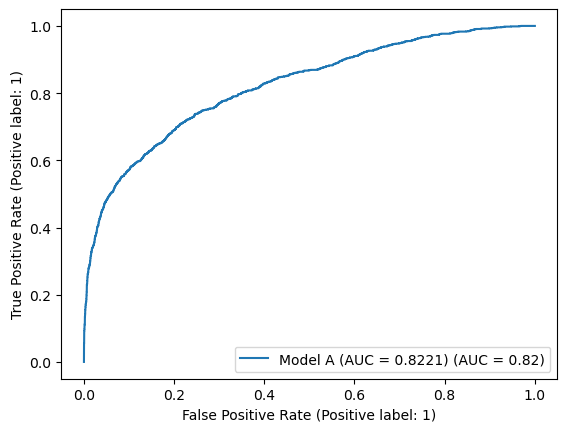

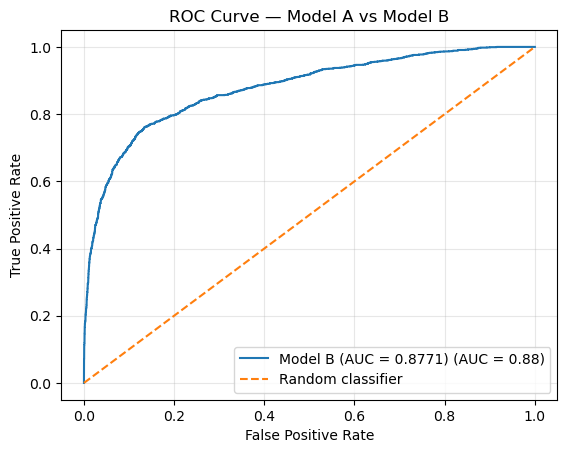

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test,
    y_a_prob,
    name=f"Model A (AUC = {model_a_results['ROC-AUC']:.4f})"
)
RocCurveDisplay.from_predictions(
    y_test,
    y_b_prob,
    name=f"Model B (AUC = {model_b_results['ROC-AUC']:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)
plt.title("ROC Curve — Model A vs Model B")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<Figure size 800x600 with 0 Axes>

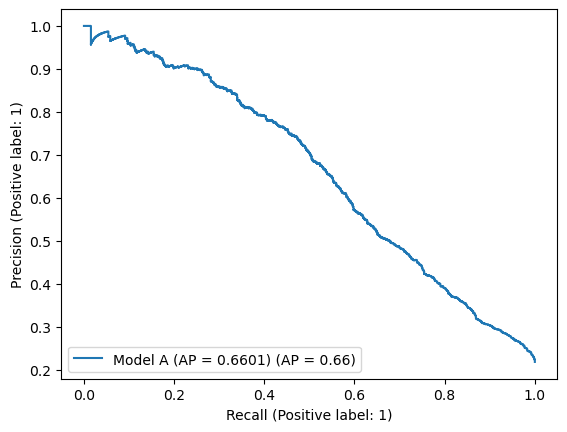

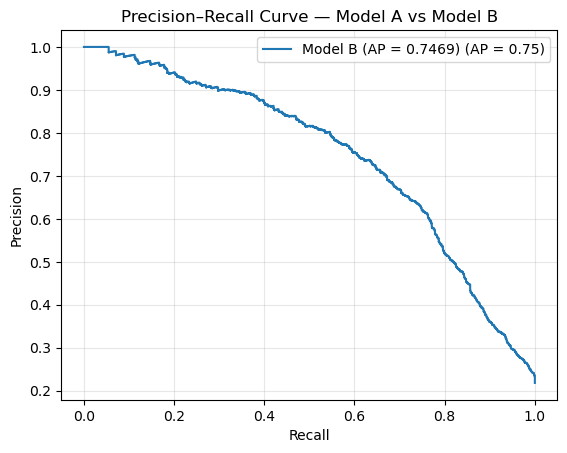

In [90]:
from sklearn.metrics import PrecisionRecallDisplay
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_a_prob,
    name=f"Model A (AP = {model_a_results['PR-AUC']:.4f})"
)
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_b_prob,
    name=f"Model B (AP = {model_b_results['PR-AUC']:.4f})"
)
plt.title("Precision–Recall Curve — Model A vs Model B")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [92]:
model_comparison = pd.DataFrame(
    [
        {
            "Model": "Model A — Applicant/Loan",
            **model_a_results
        },
        {
            "Model": "Model B — + Underwriting",
            **model_b_results
        }
    ]
)
display(
    model_comparison.round(4)
)

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
0,Model A — Applicant/Loan,0.8221,0.6601,0.8470,0.7763,0.4198,0.5450
1,Model B — + Underwriting,0.8771,0.7469,0.8702,0.7753,0.5703,0.6572


In [93]:
improvement = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Model A": [
        model_a_results["ROC-AUC"],
        model_a_results["PR-AUC"],
        model_a_results["Accuracy"],
        model_a_results["Precision"],
        model_a_results["Recall"],
        model_a_results["F1"]
    ],
    "Model B": [
        model_b_results["ROC-AUC"],
        model_b_results["PR-AUC"],
        model_b_results["Accuracy"],
        model_b_results["Precision"],
        model_b_results["Recall"],
        model_b_results["F1"]
    ]
})

improvement["Absolute Improvement"] = (
    improvement["Model B"] - improvement["Model A"]
)

display(
    improvement.round(4)
)

,Metric,Model A,Model B,Absolute Improvement
0,ROC-AUC,0.8221,0.8771,0.0550
1,PR-AUC,0.6601,0.7469,0.0869
2,Accuracy,0.8470,0.8702,0.0232
3,Precision,0.7763,0.7753,-0.0010
4,Recall,0.4198,0.5703,0.1505
5,F1,0.5450,0.6572,0.1123


In [94]:
feature_names_b = model_b.named_steps[
    "preprocessor"
].get_feature_names_out()
coefficients_b = model_b.named_steps[
    "classifier"
].coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names_b,
    "coefficient": coefficients_b
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)
display(
    coef_df.head(30).round(4)
)

,feature,coefficient,abs_coefficient
9,num__loan_to_income_ratio,7.1902,7.1902
8,num__loan_percent_income,-5.6781,5.6781
79,cat__loan_grade_G,2.9717,2.9717
73,cat__loan_grade_A,-1.9719,1.9719
74,cat__loan_grade_B,-1.7135,1.7135
19,cat__person_home_ownership_OWN,-1.6002,1.6002
75,cat__loan_grade_C,-1.5578,1.5578
78,cat__loan_grade_F,1.0193,1.0193
20,cat__person_home_ownership_RENT,0.9775,0.9775
7,num__loan_amnt,-0.7267,0.7267


In [95]:
coef_df["odds_ratio"] = np.exp(
    coef_df["coefficient"]
)
display(
    coef_df[
        [
            "feature",
            "coefficient",
            "odds_ratio"
        ]
    ].head(30).round(4)
)

,feature,coefficient,odds_ratio
9,num__loan_to_income_ratio,7.1902,1326.3647
8,num__loan_percent_income,-5.6781,0.0034
79,cat__loan_grade_G,2.9717,19.5252
73,cat__loan_grade_A,-1.9719,0.1392
74,cat__loan_grade_B,-1.7135,0.1802
19,cat__person_home_ownership_OWN,-1.6002,0.2019
75,cat__loan_grade_C,-1.5578,0.2106
78,cat__loan_grade_F,1.0193,2.7713
20,cat__person_home_ownership_RENT,0.9775,2.6577
7,num__loan_amnt,-0.7267,0.4835


In [96]:
positive_risk = (
    coef_df
    .sort_values("coefficient", ascending=False)
    .head(15)
)
negative_risk = (
    coef_df
    .sort_values("coefficient", ascending=True)
    .head(15)
)
print("=== Strongest Positive Default Associations ===")
display(
    positive_risk[
        ["feature", "coefficient", "odds_ratio"]
    ].round(4)
)
print("\n=== Strongest Negative Default Associations ===")
display(
    negative_risk[
        ["feature", "coefficient", "odds_ratio"]
    ].round(4)
)

=== Strongest Positive Default Associations ===


,feature,coefficient,odds_ratio
9,num__loan_to_income_ratio,7.1902,1326.3647
79,cat__loan_grade_G,2.9717,19.5252
78,cat__loan_grade_F,1.0193,2.7713
20,cat__person_home_ownership_RENT,0.9775,2.6577
77,cat__loan_grade_E,0.7053,2.0245
39,cat__loan_intent_HOMEIMPROVEMENT,0.5641,1.7579
18,cat__person_home_ownership_OTHER,0.5562,1.7439
76,cat__loan_grade_D,0.5508,1.7346
37,cat__loan_intent_DEBTCONSOLIDATION,0.4375,1.5488
13,num__loan_int_rate,0.1821,1.1997



=== Strongest Negative Default Associations ===


,feature,coefficient,odds_ratio
8,num__loan_percent_income,-5.6781,0.0034
73,cat__loan_grade_A,-1.9719,0.1392
74,cat__loan_grade_B,-1.7135,0.1802
19,cat__person_home_ownership_OWN,-1.6002,0.2019
75,cat__loan_grade_C,-1.5578,0.2106
7,num__loan_amnt,-0.7267,0.4835
42,cat__loan_intent_VENTURE,-0.6422,0.5261
38,cat__loan_intent_EDUCATION,-0.3581,0.6990
14,num__missingindicator_person_age,-0.2108,0.8099
72,cat__city_Victoria,-0.1524,0.8586


In [97]:
df_clean.to_csv("nova_bank_clean.csv", index=False)

In [98]:
import os
os.path.abspath("nova_bank_clean.csv")

'C:\\Users\\ASUS VIVOBOOK\\Downloads\\Nova Bank Credit Risk\\notebooks\\nova_bank_clean.csv'

In [99]:
print(df_clean.columns.tolist())
print(df_clean.shape)

['client_ID', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender', 'marital_status', 'education_level', 'country', 'state', 'city', 'city_latitude', 'city_longitude', 'employment_type', 'loan_term_months', 'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio', 'past_delinquencies', 'age_anomaly_flag', 'employment_length_anomaly_flag', 'employment_length_missing', 'interest_rate_missing', 'person_emp_length_imputed', 'lti_band', 'dti_band', 'credit_utilization_band']
(32581, 37)


In [100]:
print(df_clean.to_csv(index=False).splitlines()[0])

client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,age_anomaly_flag,employment_length_anomaly_flag,employment_length_missing,interest_rate_missing,person_emp_length_imputed,lti_band,dti_band,credit_utilization_band


In [102]:
sql_columns = [
    "client_ID",
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_status",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length",
    "gender",
    "marital_status",
    "education_level",
    "country",
    "state",
    "city",
    "city_latitude",
    "city_longitude",
    "employment_type",
    "loan_term_months",
    "loan_to_income_ratio",
    "other_debt",
    "debt_to_income_ratio",
    "open_accounts",
    "credit_utilization_ratio",
    "past_delinquencies"
]
df_sql = df_clean[sql_columns].copy()
print(df_sql.shape)
print(df_sql.columns.tolist())

(32581, 29)
['client_ID', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender', 'marital_status', 'education_level', 'country', 'state', 'city', 'city_latitude', 'city_longitude', 'employment_type', 'loan_term_months', 'loan_to_income_ratio', 'other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio', 'past_delinquencies']


In [103]:
df_sql.to_csv("nova_bank_sql.csv", index=False)
import os
os.path.abspath("nova_bank_sql.csv")

'C:\\Users\\ASUS VIVOBOOK\\Downloads\\Nova Bank Credit Risk\\notebooks\\nova_bank_sql.csv'